In [1]:
import pandas as pd
import numpy as np

In [2]:
!wget https://archive.ics.uci.edu/static/public/222/bank+marketing.zip  -O bank_marketing.zip

--2024-10-17 08:40:13--  https://archive.ics.uci.edu/static/public/222/bank+marketing.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank_marketing.zip’

bank_marketing.zip      [       <=>          ] 999.85K   638KB/s    in 1.6s    

2024-10-17 08:40:17 (638 KB/s) - ‘bank_marketing.zip’ saved [1023843]



In [3]:
!unzip bank_marketing.zip

Archive:  bank_marketing.zip
 extracting: bank.zip                
 extracting: bank-additional.zip     


In [5]:
!unzip bank.zip 

Archive:  bank.zip
  inflating: bank-full.csv           
  inflating: bank-names.txt          
  inflating: bank.csv                


In [13]:
!head -5 bank-full.csv

"age";"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"
58;"management";"married";"tertiary";"no";2143;"yes";"no";"unknown";5;"may";261;1;-1;0;"unknown";"no"
44;"technician";"single";"secondary";"no";29;"yes";"no";"unknown";5;"may";151;1;-1;0;"unknown";"no"
33;"entrepreneur";"married";"secondary";"no";2;"yes";"yes";"unknown";5;"may";76;1;-1;0;"unknown";"no"
47;"blue-collar";"married";"unknown";"no";1506;"yes";"no";"unknown";5;"may";92;1;-1;0;"unknown";"no"


In [55]:
df = pd.read_csv("bank-full.csv", sep=';')

In [56]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [57]:
df.info

<bound method DataFrame.info of        age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  d

In [23]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [58]:
col_list = ['age', 'job', 'marital', 'education', 'balance', 'housing',
       'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y']

In [59]:
df_orig = df.copy()
df = df[col_list]

In [30]:
df_orig

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [60]:
df.columns

Index(['age', 'job', 'marital', 'education', 'balance', 'housing', 'contact',
       'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'y'],
      dtype='object')

In [61]:
df['education'].nunique()

4

In [37]:
df['education'].value_counts()

secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: education, dtype: int64

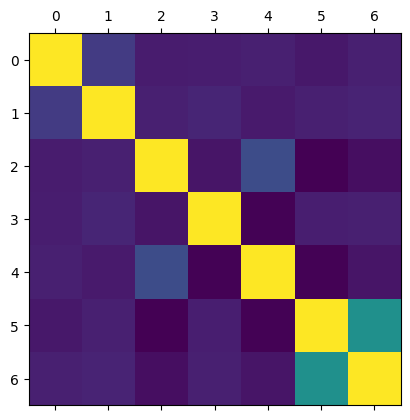

In [39]:
import matplotlib.pyplot as plt

plt.matshow(df.corr())
plt.show()

In [54]:
df.corr()

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


In [43]:
corr = df.corr().abs()
corr

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,0.009120,0.004648,0.004760,0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,0.014578,0.003435,0.016674
day,0.009120,0.004503,1.000000,0.030206,0.162490,0.093044,0.051710
duration,0.004648,0.021560,0.030206,1.000000,0.084570,0.001565,0.001203
campaign,0.004760,0.014578,0.162490,0.084570,1.000000,0.088628,0.032855
pdays,0.023758,0.003435,0.093044,0.001565,0.088628,1.000000,0.454820
previous,0.001288,0.016674,0.051710,0.001203,0.032855,0.454820,1.000000


In [63]:
s = corr.unstack()
so = s.sort_values(kind="quicksort")
so

duration  previous    0.001203
previous  duration    0.001203
          age         0.001288
age       previous    0.001288
pdays     duration    0.001565
duration  pdays       0.001565
pdays     balance     0.003435
balance   pdays       0.003435
day       balance     0.004503
balance   day         0.004503
duration  age         0.004648
age       duration    0.004648
          campaign    0.004760
campaign  age         0.004760
age       day         0.009120
day       age         0.009120
campaign  balance     0.014578
balance   campaign    0.014578
previous  balance     0.016674
balance   previous    0.016674
duration  balance     0.021560
balance   duration    0.021560
age       pdays       0.023758
pdays     age         0.023758
day       duration    0.030206
duration  day         0.030206
campaign  previous    0.032855
previous  campaign    0.032855
day       previous    0.051710
previous  day         0.051710
campaign  duration    0.084570
duration  campaign    0.084570
pdays   

In [55]:
corr.values

array([[1.        , 0.09778274, 0.00912005, 0.00464843, 0.00476031,
        0.02375801, 0.00128832],
       [0.09778274, 1.        , 0.00450259, 0.02156038, 0.01457828,
        0.00343532, 0.01667364],
       [0.00912005, 0.00450259, 1.        , 0.03020634, 0.16249022,
        0.09304407, 0.0517105 ],
       [0.00464843, 0.02156038, 0.03020634, 1.        , 0.0845695 ,
        0.00156477, 0.00120306],
       [0.00476031, 0.01457828, 0.16249022, 0.0845695 , 1.        ,
        0.08862767, 0.03285529],
       [0.02375801, 0.00343532, 0.09304407, 0.00156477, 0.08862767,
        1.        , 0.45481964],
       [0.00128832, 0.01667364, 0.0517105 , 0.00120306, 0.03285529,
        0.45481964, 1.        ]])

In [80]:
largest_10 = corr.where(~np.tril(np.ones(
    corr.shape, dtype=bool))).stack().nlargest(10)
largest_10
## In Python's NumPy library, numpy.tril is a function that returns the lower triangular part of an array or a stack of matrices: 
## np.tril([[1,2,3],[4,5,6],[7,8,9],[10,11,12]], -1) returns array([[ 0, 0, 0], [ 4, 0, 0], [ 7, 8, 0], [10, 11, 12]]) 

pdays     previous    0.454820
day       campaign    0.162490
age       balance     0.097783
day       pdays       0.093044
campaign  pdays       0.088628
duration  campaign    0.084570
day       previous    0.051710
campaign  previous    0.032855
day       duration    0.030206
age       pdays       0.023758
dtype: float64

In [81]:
df.head()

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,2143,yes,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,29,yes,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,2,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,1506,yes,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,1,no,unknown,5,may,198,1,-1,0,unknown,no


In [91]:
df['previous'].unique()

array([  0,   3,   1,   4,   2,  11,  16,   6,   5,  10,  12,   7,  18,
         9,  21,   8,  14,  15,  26,  37,  13,  25,  20,  27,  17,  23,
        38,  29,  24,  51, 275,  22,  19,  30,  58,  28,  32,  40,  55,
        35,  41])

In [90]:
df['poutcome'].unique()

array(['unknown', 'failure', 'other', 'success'], dtype=object)

In [89]:
df['campaign'].unique()

array([ 1,  2,  3,  5,  4,  6,  7,  8,  9, 10, 11, 12, 13, 19, 14, 24, 16,
       32, 18, 22, 15, 17, 25, 21, 43, 51, 63, 41, 26, 28, 55, 50, 38, 23,
       20, 29, 31, 37, 30, 46, 27, 58, 33, 35, 34, 36, 39, 44])

In [92]:
df['pdays'].unique()

array([ -1, 151, 166,  91,  86, 143, 147,  89, 140, 176, 101, 174, 170,
       167, 195, 165, 129, 188, 196, 172, 118, 119, 104, 171, 117, 164,
       132, 131, 123, 159, 186, 111, 115, 116, 173, 178, 110, 152,  96,
       103, 150, 175, 193, 181, 185, 154, 145, 138, 126, 180, 109, 158,
       168,  97, 182, 127, 130, 194, 125, 105, 102,  26, 179,  28, 183,
       155, 112, 120, 137, 124, 187, 190, 113, 162, 134, 169, 189,   8,
       144, 191, 184, 177,   5,  99, 133,  93,  92,  10, 100, 156, 198,
       106, 153, 146, 128,   7, 121, 160, 107,  90,  27, 197, 136, 139,
       122, 157, 149, 135,  30, 114,  98, 192, 163,  34,  95, 141,  31,
       199,  94, 108,  29, 268, 247, 253, 226, 244, 239, 245, 204, 231,
       238, 258, 230, 254, 265,  71, 223, 246, 250, 266, 240, 205, 261,
       259, 241, 260, 234, 251, 225, 161, 237, 262, 248, 255, 220, 227,
       206, 224, 249, 235, 228, 263,   2, 270, 232, 252, 207, 200, 269,
       233, 256, 273, 272, 242, 264, 208, 214, 222, 271, 203, 22

In [62]:
categorical = [ 'job', 'marital', 'education', 'housing', 'contact', 'month',
        'campaign', 'previous', 'poutcome']
numerical = ['age', 'balance', 
       'day', 'duration', 'pdays']

In [63]:
df.y = (df.y == 'yes').astype(int)

In [64]:
df.y.unique()

array([0, 1])

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
df_train, df_temp = train_test_split(df, test_size=0.4, random_state=42)

In [67]:
df_train.shape

(27126, 15)

In [68]:
df.shape

(45211, 15)

In [69]:
df_temp.shape

(18085, 15)

In [70]:
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)

In [71]:
df_train.shape

(27126, 15)

In [72]:
df_val.shape

(9042, 15)

In [73]:
df_test.shape

(9043, 15)

In [74]:
y_train = df_train.y.values
y_val = df_val.y.values

In [75]:
from sklearn.metrics import mutual_info_score

In [76]:
def calculate_mi(series):
    return mutual_info_score(series, df_train.y).round(2)

df_mi = df_train[categorical].apply(calculate_mi)
df_mi = df_mi.sort_values(ascending=False).to_frame(name='MI')


display(df_mi.head())
display(df_mi.tail())

,MI
poutcome,0.03
month,0.02
job,0.01
housing,0.01
contact,0.01


,MI
contact,0.01
previous,0.01
marital,0.00
education,0.00
campaign,0.00


In [77]:
del df_train['y']
del df_val['y']

In [78]:
y_train.shape

(27126,)

In [79]:
type(y_train)

numpy.ndarray

In [80]:
from sklearn.feature_extraction import DictVectorizer

In [81]:
train_dict = df_train[categorical + numerical].to_dict(orient='records')

In [82]:
train_dict[0:4]

[{'job': 'entrepreneur',
  'marital': 'married',
  'education': 'primary',
  'housing': 'yes',
  'contact': 'unknown',
  'month': 'may',
  'campaign': 6,
  'previous': 0,
  'poutcome': 'unknown',
  'age': 45,
  'balance': -100,
  'day': 27,
  'duration': 240,
  'pdays': -1},
 {'job': 'services',
  'marital': 'single',
  'education': 'secondary',
  'housing': 'no',
  'contact': 'cellular',
  'month': 'jul',
  'campaign': 8,
  'previous': 0,
  'poutcome': 'unknown',
  'age': 29,
  'balance': 166,
  'day': 28,
  'duration': 108,
  'pdays': -1},
 {'job': 'admin.',
  'marital': 'single',
  'education': 'secondary',
  'housing': 'yes',
  'contact': 'unknown',
  'month': 'may',
  'campaign': 1,
  'previous': 0,
  'poutcome': 'unknown',
  'age': 31,
  'balance': 121,
  'day': 20,
  'duration': 187,
  'pdays': -1},
 {'job': 'self-employed',
  'marital': 'single',
  'education': 'tertiary',
  'housing': 'yes',
  'contact': 'cellular',
  'month': 'nov',
  'campaign': 1,
  'previous': 0,
  'poutco

In [83]:
dv = DictVectorizer(sparse=False)
#dv.fit(train_dict)

In [84]:
X_train = dv.fit_transform(train_dict)

In [85]:
df_train.shape

(27126, 14)

In [86]:
X_train.shape

(27126, 47)

In [87]:
X_train[0]

array([  45., -100.,    6.,    0.,    0.,    1.,   27.,  240.,    1.,
          0.,    0.,    0.,    0.,    1.,    0.,    0.,    1.,    0.,
          0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          1.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          0.,    1.,    0.,    0.,    0.,   -1.,    0.,    0.,    0.,
          1.,    0.])

In [88]:
type(X_train)

numpy.ndarray

In [89]:
type(dv)

sklearn.feature_extraction._dict_vectorizer.DictVectorizer

In [90]:
dv.get_feature_names_out() # get_feature_names() is not working

array(['age', 'balance', 'campaign', 'contact=cellular',
       'contact=telephone', 'contact=unknown', 'day', 'duration',
       'education=primary', 'education=secondary', 'education=tertiary',
       'education=unknown', 'housing=no', 'housing=yes', 'job=admin.',
       'job=blue-collar', 'job=entrepreneur', 'job=housemaid',
       'job=management', 'job=retired', 'job=self-employed',
       'job=services', 'job=student', 'job=technician', 'job=unemployed',
       'job=unknown', 'marital=divorced', 'marital=married',
       'marital=single', 'month=apr', 'month=aug', 'month=dec',
       'month=feb', 'month=jan', 'month=jul', 'month=jun', 'month=mar',
       'month=may', 'month=nov', 'month=oct', 'month=sep', 'pdays',
       'poutcome=failure', 'poutcome=other', 'poutcome=success',
       'poutcome=unknown', 'previous'], dtype=object)

In [91]:
from sklearn.linear_model import LogisticRegression

In [38]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [92]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [93]:
X_val[0]

array([ 36., 565.,   1.,   1.,   0.,   0.,  27., 300.,   0.,   1.,   0.,
         0.,   1.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,  -1.,   0.,   0.,
         0.,   1.,   0.])

In [94]:
model.predict_proba(X_val)

array([[0.52071208, 0.47928792],
       [0.98825536, 0.01174464],
       [0.78327293, 0.21672707],
       ...,
       [0.9667054 , 0.0332946 ],
       [0.9426242 , 0.0573758 ],
       [0.98056344, 0.01943656]])

In [97]:
y_pred = model.predict_proba(X_val)[:, 1]

In [98]:
y_pred

array([0.47928792, 0.01174464, 0.21672707, ..., 0.0332946 , 0.0573758 ,
       0.01943656])

In [101]:
subscribed_td = y_pred > 0.5

In [102]:
(y_val == subscribed_td).mean()

0.9007962840079629

In [103]:
(y_val == subscribed_td).mean().round(2)

0.9

In [119]:
feature_list = ['age', 'balance', 'marital', 'previous']

In [111]:
from IPython.display import display

In [142]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)

accr = {}
for f in ['age', 'balance', 'marital', 'previous']:
# for f in ['age']:
    all_features = categorical + numerical
    all_features.remove(f)
    features = all_features.copy()
    print(features)
    train_dict = df_train[features].to_dict(orient='records')
    dv = DictVectorizer(sparse=False)
    dv.fit(train_dict)
    X_train = dv.transform(train_dict)
    model.fit(X_train, y_train)
    val_dict = df_val[features].to_dict(orient='records')
    X_val = dv.transform(val_dict)
    y_pred = model.predict_proba(X_val)[:, 1]
    subscribed_td = y_pred > 0.5
    accr[f] = (y_val == subscribed_td).mean().round(4)
accr
    

['job', 'marital', 'education', 'housing', 'contact', 'month', 'campaign', 'previous', 'poutcome', 'balance', 'day', 'duration', 'pdays']
['job', 'marital', 'education', 'housing', 'contact', 'month', 'campaign', 'previous', 'poutcome', 'age', 'day', 'duration', 'pdays']
['job', 'education', 'housing', 'contact', 'month', 'campaign', 'previous', 'poutcome', 'age', 'balance', 'day', 'duration', 'pdays']
['job', 'marital', 'education', 'housing', 'contact', 'month', 'campaign', 'poutcome', 'age', 'balance', 'day', 'duration', 'pdays']


{'age': 0.901, 'balance': 0.9008, 'marital': 0.9011, 'previous': 0.9007}